In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Gathering

In [2]:
df = pd.read_csv(r"D:\AI\Genrative ai\Deep learning\Ann\huge_1M_titanic.csv")

## Data Perprocessing

In [3]:
df.shape

(1000000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   PassengerId  1000000 non-null  int64  
 1   Survived     1000000 non-null  int64  
 2   Pclass       1000000 non-null  int64  
 3   Name         1000000 non-null  object 
 4   Sex          1000000 non-null  object 
 5   Age          801400 non-null   float64
 6   SibSp        1000000 non-null  int64  
 7   Parch        1000000 non-null  int64  
 8   Ticket       1000000 non-null  object 
 9   Fare         1000000 non-null  float64
 10  Cabin        229805 non-null   object 
 11  Embarked     997760 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 91.6+ MB


In [5]:
df.isnull().sum()

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age            198600
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin          770195
Embarked         2240
dtype: int64

In [6]:
# Remove the columns
df = df.drop(columns = ["PassengerId","Name","Age","Ticket","Cabin"])

In [7]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [8]:
df.isnull().sum()

Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Embarked    2240
dtype: int64

In [9]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace = True)

C:\Users\Om\AppData\Local\Temp\ipykernel_23596\2929921552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace = True)


In [10]:
df

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked
0,1,1,female,0,0,76.760165,C
1,0,3,male,0,0,10.193097,S
2,0,3,male,0,0,12.029416,C
3,0,3,male,0,0,13.429448,S
4,0,3,male,0,0,4.840769,C
...,...,...,...,...,...,...,...
999995,0,2,male,0,0,26.196512,S
999996,1,1,female,0,0,102.555248,S
999997,0,3,male,1,0,8.274807,S
999998,0,2,male,1,0,0.000000,S


In [11]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [12]:
df.duplicated().sample(10)

300215    False
936826    False
747053    False
595244    False
193980    False
32966     False
739585    False
612391     True
702551    False
80020     False
dtype: bool

# Data Cleaning

In [13]:
df["Embarked"] = df["Embarked"].replace({"S":"Sounthampton","C":"Chebourg","Q":"Queenstown"})

In [14]:
df["Fare"].fillna(0, inplace=True)
df["Fare"] = df["Fare"].astype("int64")

C:\Users\Om\AppData\Local\Temp\ipykernel_23596\2982717060.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Fare"].fillna(0, inplace=True)


 ## Feature Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df["Sex"])
df["Sex"] = le.transform(df["Sex"])

In [16]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(df[["Embarked"]])
df[["Sounthampton","Chebourg","Queenstown"]] = ohe.transform(df[["Embarked"]]).toarray()

In [17]:
df.describe()

,Survived,Pclass,Sex,SibSp,Parch,Fare,Sounthampton,Chebourg,Queenstown
count,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.381681,2.31125,0.648840,0.511101,0.360037,32.992748,0.186846,0.081446,0.731708
std,0.485799,0.83577,0.477333,1.104846,0.767296,47.955593,0.389788,0.273519,0.443071
min,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.00000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000
50%,0.000000,3.00000,1.000000,0.000000,0.000000,15.000000,0.000000,0.000000,1.000000
75%,1.000000,3.00000,1.000000,1.000000,0.000000,35.000000,0.000000,0.000000,1.000000
max,1.000000,3.00000,1.000000,8.000000,6.000000,640.000000,1.000000,1.000000,1.000000


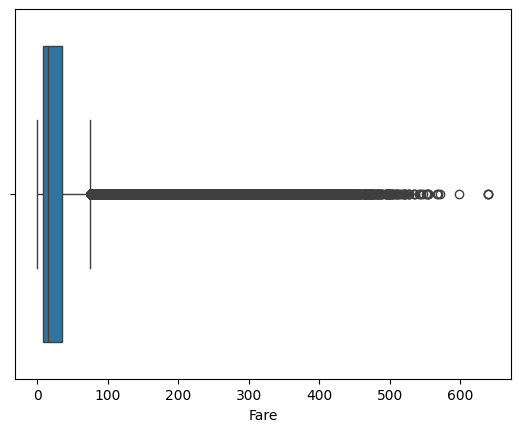

In [18]:
sns.boxplot(x= "Fare",data = df)
plt.show()

## Data Scaling

In [19]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
num_cols = ["Pclass","SibSp","Parch","Fare"]

df[num_cols] = ss.fit_transform(df[num_cols])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Survived      1000000 non-null  int64  
 1   Pclass        1000000 non-null  float64
 2   Sex           1000000 non-null  int64  
 3   SibSp         1000000 non-null  float64
 4   Parch         1000000 non-null  float64
 5   Fare          1000000 non-null  float64
 6   Embarked      1000000 non-null  object 
 7   Sounthampton  1000000 non-null  float64
 8   Chebourg      1000000 non-null  float64
 9   Queenstown    1000000 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 76.3+ MB


In [21]:
import pickle

In [22]:
with open("Label_encoder.pkl","wb") as f:
  pickle.dump(le,f)

In [23]:
with open("onehot_encoder.pkl","wb") as f:
  pickle.dump(ohe,f)

In [24]:
with open("scaler_encoder.pkl","wb") as f:
  pickle.dump(ss,f)

## Train _Validation_Test-Split

In [25]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ["Survived", "Embarked"])
y = df["Survived"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

### Again Train split into a validation

In [26]:
X_train,X_valid,y_train,y_valid=train_test_split(X_train,y_train,test_size = 0.2,random_state=42)

In [27]:
X_train.shape

(640000, 8)

In [28]:
X_valid.shape

(160000, 8)

In [30]:
import tensorflow

### Model building

In [ ]:
(X_train.shape[1],)

(8,)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential([
    Dense(64,input_shape=(X_train.shape[1],), # first hidden layer
          activation = "relu"),
           Dense(32,activation = "relu"),
           Dense(1,activation = "sigmoid")])

c:\Users\Om\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation ---> Optimizer , Loss , Metrix

In [ ]:
opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01)
tensorflow.keras.losses.BinaryCrossentropy()
tensorflow.keras.metrics.Accuracy()

<Accuracy name=accuracy>

In [ ]:
model.compile(
    optimizer = opt,
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
Stopping_callback = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [ ]:
model.fit(X_train,y_train,validation_data = (X_valid,y_valid),
          epochs = 10,
          callbacks = [Stopping_callback])

Epoch 1/10
 8553/20000 ━━━━━━━━━━━━━━━━━━━━ 9s 815us/step - accuracy: 0.8376 - loss: 0.3668

In [ ]:
model.save("model.h5")